# RGB point time series

Extract the red, green, and blue values from all Colorado RGB composite NetCDF files for the grid cell nearest to `38.958N, 106.990W`.

In [9]:
from glob import glob
from pathlib import Path
import matplotlib.pyplot as plt

import pandas as pd
import xarray as xr

rgb_dir = Path('/glade/u/home/cdalden/scratch/colorado/goes16/rgb_composite')
target_lat = 38.958
target_lon = -106.990

files = sorted(glob(str(rgb_dir / '*.nc')))
len(files)

607

In [3]:
frames = []
selected_lat = None
selected_lon = None

for file in files:
    with xr.open_dataset(file) as ds:
        point = ds.sel(latitude=target_lat, longitude=target_lon, method='nearest')
        print(f'Processing {file}')
        if selected_lat is None:
            selected_lat = float(point.latitude)
            selected_lon = float(point.longitude)

        point_df = point[['red', 'green', 'blue']].to_dataframe().reset_index()
        point_df['source_file'] = Path(file).name
        frames.append(point_df)

rgb_ts_df = (
    pd.concat(frames, ignore_index=True)
    .sort_values('t')
    .reset_index(drop=True)
)

rgb_ts_df = rgb_ts_df.rename(columns={'t': 'time'})
rgb_ts_df['target_lat'] = target_lat
rgb_ts_df['target_lon'] = target_lon
rgb_ts_df['grid_lat'] = selected_lat
rgb_ts_df['grid_lon'] = selected_lon

print(f'Nearest grid cell: ({selected_lat:.6f}, {selected_lon:.6f})')
rgb_ts_df.head()

Processing /glade/u/home/cdalden/scratch/colorado/goes16/rgb_composite/goes16_C02_C05_C13_rgb_colorado_20211001.nc
Processing /glade/u/home/cdalden/scratch/colorado/goes16/rgb_composite/goes16_C02_C05_C13_rgb_colorado_20211002.nc
Processing /glade/u/home/cdalden/scratch/colorado/goes16/rgb_composite/goes16_C02_C05_C13_rgb_colorado_20211003.nc
Processing /glade/u/home/cdalden/scratch/colorado/goes16/rgb_composite/goes16_C02_C05_C13_rgb_colorado_20211004.nc
Processing /glade/u/home/cdalden/scratch/colorado/goes16/rgb_composite/goes16_C02_C05_C13_rgb_colorado_20211005.nc
Processing /glade/u/home/cdalden/scratch/colorado/goes16/rgb_composite/goes16_C02_C05_C13_rgb_colorado_20211006.nc
Processing /glade/u/home/cdalden/scratch/colorado/goes16/rgb_composite/goes16_C02_C05_C13_rgb_colorado_20211007.nc
Processing /glade/u/home/cdalden/scratch/colorado/goes16/rgb_composite/goes16_C02_C05_C13_rgb_colorado_20211008.nc
Processing /glade/u/home/cdalden/scratch/colorado/goes16/rgb_composite/goes16_C0

,time,red,green,blue,longitude,latitude,source_file,target_lat,target_lon,grid_lat,grid_lon
0,2021-10-01 00:02:30,0.21373,0.075764,0.040786,-106.987887,38.956539,goes16_C02_C05_C13_rgb_colorado_20211001.nc,38.958,-106.99,38.956539,-106.987887
1,2021-10-01 00:07:30,0.21373,0.075764,0.040786,-106.987887,38.956539,goes16_C02_C05_C13_rgb_colorado_20211001.nc,38.958,-106.99,38.956539,-106.987887
2,2021-10-01 00:12:30,0.21373,0.075764,0.040786,-106.987887,38.956539,goes16_C02_C05_C13_rgb_colorado_20211001.nc,38.958,-106.99,38.956539,-106.987887
3,2021-10-01 00:17:30,0.21373,0.075764,0.040786,-106.987887,38.956539,goes16_C02_C05_C13_rgb_colorado_20211001.nc,38.958,-106.99,38.956539,-106.987887
4,2021-10-01 00:22:30,0.21373,0.075764,0.040786,-106.987887,38.956539,goes16_C02_C05_C13_rgb_colorado_20211001.nc,38.958,-106.99,38.956539,-106.987887


In [24]:
tsi_path ='/glade/u/home/cdalden/scratch/surface_obs/colorado/sail_tsi_cloud_frac.csv'
tsi_df = pd.read_csv(tsi_path, parse_dates=['t'])
tsi_df.set_index('t', inplace=True)
rgb_ts_df['tsi_frac'] = tsi_df['tsi_frac']
rgb_ts_df.head()

,time,red,green,blue,longitude,latitude,source_file,target_lat,target_lon,grid_lat,grid_lon,tsi_frac
0,2021-10-01 00:02:30,0.21373,0.075764,0.040786,-106.987887,38.956539,goes16_C02_C05_C13_rgb_colorado_20211001.nc,38.958,-106.99,38.956539,-106.987887,NaN
1,2021-10-01 00:07:30,0.21373,0.075764,0.040786,-106.987887,38.956539,goes16_C02_C05_C13_rgb_colorado_20211001.nc,38.958,-106.99,38.956539,-106.987887,NaN
2,2021-10-01 00:12:30,0.21373,0.075764,0.040786,-106.987887,38.956539,goes16_C02_C05_C13_rgb_colorado_20211001.nc,38.958,-106.99,38.956539,-106.987887,NaN
3,2021-10-01 00:17:30,0.21373,0.075764,0.040786,-106.987887,38.956539,goes16_C02_C05_C13_rgb_colorado_20211001.nc,38.958,-106.99,38.956539,-106.987887,NaN
4,2021-10-01 00:22:30,0.21373,0.075764,0.040786,-106.987887,38.956539,goes16_C02_C05_C13_rgb_colorado_20211001.nc,38.958,-106.99,38.956539,-106.987887,NaN


Text(0.5, 1.0, 'Green')

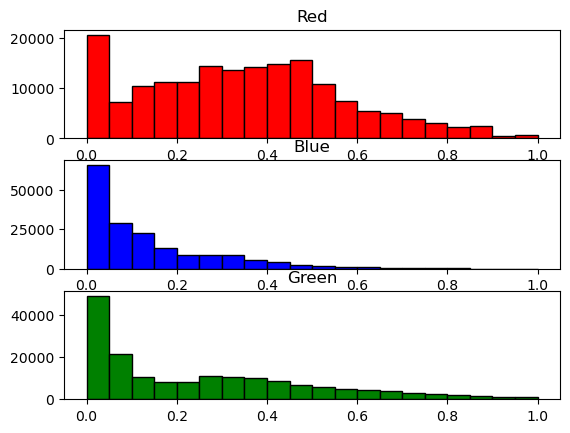

In [15]:
fig, ax = plt.subplots(3,1)

ax[0].hist(rgb_ts_df.red, color='r', ec='k', bins=20)
ax[0].set_title('Red')

ax[1].hist(rgb_ts_df.blue, color='b', ec='k', bins=20)
ax[1].set_title('Blue')

ax[2].hist(rgb_ts_df.green, color='g', ec='k', bins=20)
ax[2].set_title('Green')

In [16]:
out_name = 'gothic_pixel_rgb.csv'
rgb_ts_df.to_csv(out_name)